*Built with Grok Build*

# Homework Module 13


In [2]:
##########################################################################################
# EEE591_419 Python for Rapid Engineering Solutions - HW_M13: HW13_Mark_Khusid.py
# Mark Khusid
##########################################################################################

##########################################################################################
# MW_M13
#                    
##########################################################################################


## Import Libraries


In [3]:
import math
import tkinter as tk
from tkinter import messagebox

import matplotlib.pyplot as plt
import numpy as np


## Set Debug State


In [4]:
debug = False


## Create Basic Calculator Class


In [5]:
class BasicCalculator:
    """
    A simple OOP Calculator class that supports basic arithmetic operations.
    """

    def __init__(self, name="Basic Calculator"):
        self.name = name # Just something to have here.
        if debug:
            print(f"[*] Instantiated Basic Calculator.  Called from: {self.name}")

    def add(self, first_number: float, second_number: float) -> float:
        """ Add two numbers """
        return first_number + second_number

    def subtract(self, first_number: float, second_number: float) -> float:
        """ Subtract two numbers """
        return first_number - second_number

    def multiply(self, first_number: float, second_number: float) -> float:
        """ Multiply two numbers """
        return first_number * second_number

    def divide(self, first_number: float, second_number: float) -> float:
        """ Divide two number but first check for div by 0 """
        if second_number == 0:
            raise ValueError("Division by zero is not allowed.")
        return first_number / second_number


### Test Code for Basic Calculator Class


In [6]:
if debug:
    calc = BasicCalculator()
    
    print("=== Basic Calculator Test ===\n")
    
    # Test each operation
    print(f"5 + 3 = {calc.add(5, 3)}")
    print(f"10 - 4 = {calc.subtract(10, 4)}")
    print(f"6 * 7 = {calc.multiply(6, 7)}")
    print(f"20 / 5 = {calc.divide(20, 5)}")
    
    # Test floating point
    print(f"7.5 * 2.3 = {calc.multiply(7.5, 2.3)}")
    
    # Test error handling
    try:
        print(f"10 / 0 = {calc.divide(10, 0)}")
    except ValueError as e:
        print(f"Error: {e}")


## Create Scientific Calculator Class


In [7]:
class ScientificCalculator(BasicCalculator):
    """
    ScientificCalculator inherits from Calculator and adds:
    - Logarithm (base 10)
    - Exponentiation (base 10)
    - Sine and Cosine (in radians)
    """

    def __init__(self, name="Scientific Calculator", base=2):
        super().__init__(name)
        self.base = base
        if debug:
            print(f"[*] Instantiated Scientific Calculator.  Called from: {self.name}")
            print(f"[*] Base = {self.base}")

    def log(self, number: float) -> float:
        """
        Return log_base(number), where base is stored in the calculator.
        Checks to make sure that the entered number is positive and that
        the logarithmic base is not negative or equal to 1
        """
        if number <= 0:
            raise ValueError("Logarithm input must be positive.")
        if self.base <= 0 or self.base == 1:
            raise ValueError("Logarithm base must be positive and not equal to 1.")
        return math.log(number, self.base)

    def exponent(self, number: float) -> float:
        """Return base ** number, where base is stored in the calculator."""
        return self.base ** number

    def sine(self, angle_radians: float) -> float:
        """Return sin(angle_radians)."""
        return math.sin(angle_radians)

    def cosine(self, angle_radians: float) -> float:
        """Return cos(angle_radians)."""
        return math.cos(angle_radians)


### Test Code for Scientific Calculator


In [8]:
if debug:
    print("=== Scientific Calculator Test ===\n")
    
    sci_calc = ScientificCalculator()
    
    # Test inherited basic operations
    print("Basic Operations (inherited):")
    print(f"5 + 3 = {sci_calc.add(5, 3)}")
    print(f"20 / 4 = {sci_calc.divide(20, 4)}")
    
    # Test new scientific operations
    print("\nScientific Operations:")
    print(f"log2(1024)  = {sci_calc.log(1024)}")           # Should be 10.0
    print(f"2^3         = {sci_calc.exponent(3)}")         # Should be 8
    print(f"sin(π/2)    = {sci_calc.sine(math.pi/2):.6f}") # Should be 1.0
    print(f"cos(π)      = {sci_calc.cosine(math.pi):.6f}") # Should be -1.0


## Create Graphing Calculator Class


In [9]:
class GraphicalCalculator(ScientificCalculator):
    """A graphical calculator that can plot a user-provided y-array."""

    def __init__(
        self,
        name="Graphical Calculator",
        base=10,
        x_start=-10,
        x_stop=10,
    ):
        super().__init__(name, base)
        self.x_start = x_start
        self.x_stop = x_stop
        if debug:
            print(f"[*] Instantiated Graphing Calculator.  Called from: {self.name}")
            print(f"[*] Base = {self.base}")
            print(f"[*] X-axis start = {self.x_start}")
            print(f"[*] X-axis stop  = {self.x_stop}")

    def plot_curve(self, y_values_list: list[float], title: str = "Graphical Calculator Curve"):
        """
        Plot y_values versus x-axis.

        The user supplies y_values. The x-axis is fixed.
        """
        if debug:
            print(f"[*] In plot_curve(), received y_values_list: {y_values_list}")
        y_array = np.asarray(y_values_list, dtype=float)

        if y_array.size == 0:
            raise ValueError("The y-array must contain at least one value.")

        x_array = np.linspace(self.x_start, self.x_stop, y_array.size)

        plt.figure(figsize=(12, 5))
        plt.plot(x_array, y_array, marker="o", label="Input y-array")
        plt.title(title)
        plt.xlabel("Custom x-axis from calculator")
        plt.ylabel("User-provided y-values")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        return x_array, y_array

    def plot_user_input(self, title: str = "Graphical Calculator Curve (Manual Entry)"):
        """
        Ask the user for any number of y-values and intelligently map them to x-axis:
          - ≤ 10 numbers  → x from 0 to 10
          - > 10 numbers  → x from -10 to 10
        """
        print("=== Plot User-Provided Y Values ===")
        print("You can enter numbers separated by spaces or commas.")
        print("Example: 1.5 2.3 -4 0 5.7\n")
        
        while True:
            try:
                user_input = input("Enter your y values: ").strip()
                if not user_input:
                    print("Please enter at least one number.")
                    continue
                
                # Clean and parse input
                # Replace commas with spaces and split
                cleaned = user_input.replace(',', ' ')
                y_str_list = cleaned.split()
                
                y_values = []
                for s in y_str_list:
                    try:
                        y_values.append(float(s))
                    except ValueError:
                        print(f"Invalid number skipped: '{s}'")
                        continue
                
                if not y_values:
                    print("No valid numbers entered. Please try again.")
                    continue
                
                num_points = len(y_values)
                if debug:
                    print(f"Received {num_points} valid y values.")
                
                # Determine x range based on number of points
                if num_points <= 10:
                    x_min = 0.0
                    x_max = self.x_stop
                    if debug:
                        print(f"Using x-axis from {x_min} to {x_max} ({num_points} points)")
                else:
                    x_min = self.x_start
                    x_max = self.x_stop
                    if debug:
                        print(f"Using x-axis from {x_min} to {x_max} ({num_points} points)")
                
                # Generate x values
                step = (x_max - x_min) / (num_points - 1) if num_points > 1 else 0
                x_values = [x_min + i * step for i in range(num_points)]
                
                # Plot
                plt.figure(figsize=(12, 5))
                plt.plot(x_values, y_values, 'b-', linewidth=2.5, marker='o', markersize=4)
                plt.title(title)
                plt.xlabel("X")
                plt.ylabel("Y")
                plt.grid(True)
                plt.axhline(0, color='black', linewidth=0.5)
                plt.axvline(0, color='black', linewidth=0.5)
                plt.show()
                
                return  # Exit after successful plot
                
            except Exception as e:
                print(f"Unexpected error: {e}")
                print("Please try entering the numbers again.\n")


### Test Code for Graphing Calculator


In [10]:
if debug:
    print("=== Graphing Calculator Demo ===\n")
    
    graph_calc = GraphicalCalculator()
    
    # Example 1: Plot a quadratic function using inherited scientific capabilities
    #print("Plotting y = x² - 5")
    #curve = [(x**2 - 5) for x in range(-10, 11)]
    #graph_calc.plot_curve(curve, title="y = x² - 5")
    
    # Example 2: Manual y values
    print("\nPlotting custom y values...")
    graph_calc.plot_user_input()


## Create Basic Calculator GUI Class


In [11]:
class BasicCalculatorGUI(BasicCalculator):
    """A GUI calculator for the four BasicCalculator operations."""

    def __init__(
        self,
        name="GUI Calculator",
        default_first_number=6.0,
        default_second_number=7.0, # because my daughter laughs at the number "67".  I am not sure why.
    ):
        super().__init__(name)
        self.default_first_number = default_first_number
        self.default_second_number = default_second_number
        self.window = None
        self.first_entry = None
        self.second_entry = None
        self.result_label = None
        if debug:
            print(f"[*] Instantiated GUI Calculator.  Called from: {self.name}")

    def _read_inputs(self):
        """Read and convert the two GUI textbox values."""
        try:
            first_number = float(self.first_entry.get())
            second_number = float(self.second_entry.get())
            return first_number, second_number
        except ValueError as error:
            raise ValueError("Both textboxes must contain valid numbers.") from error

    def _run_operation(self, operation):
        """Execute a selected calculator operation and display the result."""
        try:
            first_number, second_number = self._read_inputs()
            result = operation(first_number, second_number)
            self.result_label.config(text=f"Result: {result:.6g}")
        except ValueError as error:
            messagebox.showerror("Calculator Error", str(error))

    def display(self):
        """Create and display the GUI window."""
        self.window = tk.Tk()
        self.window.title(self.name)
        self.window.geometry("460x300")
        self.window.configure(bg="#ddeeff")

        title_label = tk.Label(
            self.window,
            text=self.name,
            font=("Arial", 17, "bold"),
            bg="#ddeeff",
        )
        title_label.grid(row=0, column=0, columnspan=2, padx=12, pady=12)

        self.first_entry = tk.Entry(self.window, width=18, font=("Consolas", 14))
        self.first_entry.insert(0, str(self.default_first_number))
        self.first_entry.grid(row=1, column=0, padx=15, pady=10)

        self.second_entry = tk.Entry(self.window, width=18, font=("Consolas", 14))
        self.second_entry.insert(0, str(self.default_second_number))
        self.second_entry.grid(row=1, column=1, padx=15, pady=10)

        self.result_label = tk.Label(
            self.window,
            text="Result will appear here",
            font=("Arial", 15),
            width=28,
            bg= "#225577",
            fg= "white",
        )
        self.result_label.grid(row=2, column=0, columnspan=2, padx=12, pady=15)

        button_settings = {
            "font": ("Arial", 13, "bold"),
            "width": 13,
            "height": 2,
            "bg": "#225577",
            "fg": "white",
        }

        add_button = tk.Button(
            self.window,
            text="Add",
            command=lambda: self._run_operation(self.add),
            **button_settings,
        )
        add_button.grid(row=3, column=0, padx=10, pady=7)

        subtract_button = tk.Button(
            self.window,
            text="Subtract",
            command=lambda: self._run_operation(self.subtract),
            **button_settings,
        )
        subtract_button.grid(row=3, column=1, padx=10, pady=7)

        multiply_button = tk.Button(
            self.window,
            text="Multiply",
            command=lambda: self._run_operation(self.multiply),
            **button_settings,
        )
        multiply_button.grid(row=4, column=0, padx=10, pady=7)

        divide_button = tk.Button(
            self.window,
            text="Divide",
            command=lambda: self._run_operation(self.divide),
            **button_settings,
        )
        divide_button.grid(row=4, column=1, padx=10, pady=7)

        self.window.mainloop()


### Test Code for Basic Calculator GUI


In [12]:
if debug:
    gui_calculator = BasicCalculatorGUI(
        default_first_number=6.0,
        default_second_number=7.0,
    )
    gui_calculator.display()


## How the calculator hierarchy is supposed to work

This assignment builds a small **object-oriented calculator stack** in Python:

1. **`BasicCalculator`** — OOP class with `add`, `subtract`, `multiply`, and `divide` (with divide-by-zero handling).
2. **`ScientificCalculator`** — subclasses the basic calculator and adds log/exponent (configurable base) plus sine/cosine.
3. **`GraphicalCalculator`** — subclasses the scientific calculator and can plot a curve over an `x` range via Matplotlib (`plot_curve` / optional interactive `plot_user_input`).
4. **`BasicCalculatorGUI`** — subclasses the basic calculator and wraps it in a **Tkinter** window: entry fields for two numbers, buttons for the four operations, and a result label. Calling `.display()` starts the Tk event loop (`mainloop`), which blocks until the window is closed.

### Running the GUI locally (not on the website)

In a desktop Python environment with Tk support:

```python
gui = BasicCalculatorGUI(default_first_number=6.0, default_second_number=7.0)
gui.display()  # opens a window; close it when finished
```

The notebook demonstration below runs only the **non-blocking** pieces (basic/scientific math and a static plot) so the site build does not hang on a GUI.


Basic calculator sample:
12 * 9 = 108

Scientific calculator sample:
log base 2 of 2048 = 11.0

Graphical calculator sample:
Plotting hard-coded y-array: [3, 7, 2, 9, 5, 12, 6, 10]


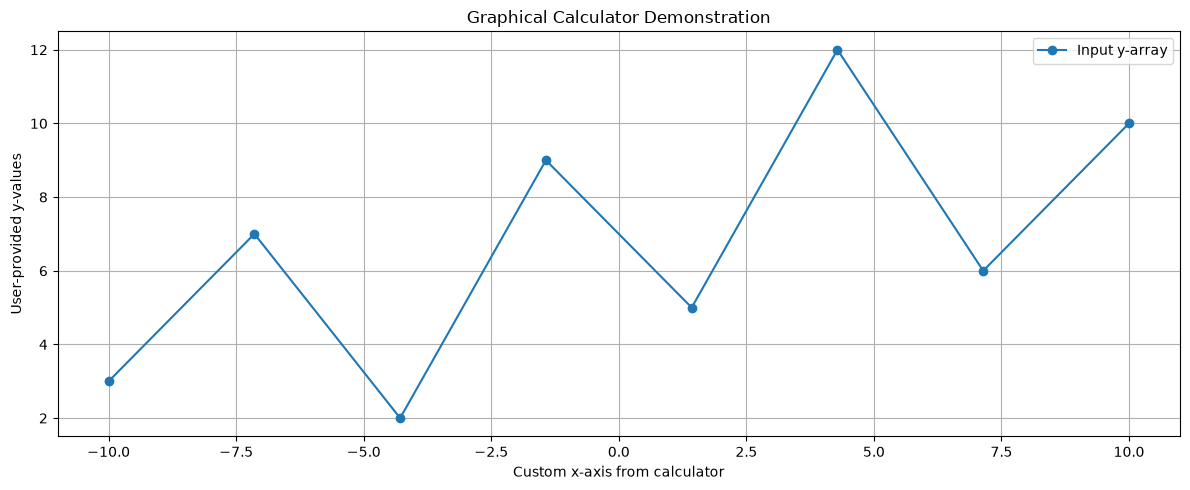

Graphical calculator demo finished.

GUI calculator: not launched in notebook/website mode.
Locally, construct BasicCalculatorGUI(...) and call .display() to open Tkinter.


In [13]:
if __name__ == "__main__":
    # ================================================================
    # Demonstration section (non-interactive / website-safe)
    # ================================================================
    # Note: The Tkinter GUI calculator is intentionally NOT launched here
    # so notebook builds and site execution do not block on a window.
    # See the markdown description above for how to run the GUI locally.

    # 1. Demonstrate one basic calculator functionality.
    basic_calculator = BasicCalculator()
    basic_result = basic_calculator.multiply(12, 9)
    print("Basic calculator sample:")
    print(f"12 * 9 = {basic_result}")
    print()

    # 2. Demonstrate one scientific calculator functionality.
    scientific_calculator = ScientificCalculator(base=2)
    scientific_result = scientific_calculator.log(2048)
    print("Scientific calculator sample:")
    print(f"log base 2 of 2048 = {scientific_result}")
    print()

    # 3. Demonstrate graphical calculator with a hard-coded y-array (no user input).
    graphical_calculator = GraphicalCalculator(x_start=-10.0, x_stop=10.0)
    demo_y_values = [3, 7, 2, 9, 5, 12, 6, 10]
    print("Graphical calculator sample:")
    print("Plotting hard-coded y-array:", demo_y_values)
    graphical_calculator.plot_curve(
        demo_y_values,
        title="Graphical Calculator Demonstration",
    )
    print("Graphical calculator demo finished.")
    print()

    # 4. GUI calculator — not started in this notebook run.
    print("GUI calculator: not launched in notebook/website mode.")
    print("Locally, construct BasicCalculatorGUI(...) and call .display() to open Tkinter.")
